In [1]:
import pandas as pd
import numpy as np
import os
import pysam

def alelles_at_read_position(read, position):
    """ Get allele at current select position in the read.
    :param read: the current read from samfile.fetch
    :param position: position based on reference coordinates
    """
    reference_positions = read.get_reference_positions()
    sequence = list(read.query_alignment_sequence)
    position_index = reference_positions.index(position-1)
    return(sequence[position_index])

def get_reads_supported_by_allele_snv(chrom, position, cram, reference):
    """ Get dictionary of reads that support the allele at the position
    :param chrom: chromosome input
    :param pos: position in the reference genome
    :param cram: cram file containing aligned reads
    :param reference: reference genome fasta file
    """
    handle = pysam.AlignmentFile(cram, "rc", reference_filename = reference)
    reads_by_allele = {base : [] for base in "ACGTN"}
    for read in handle.fetch(chrom, pos-1, pos):
        allele = alelles_at_read_position(read, position)
        reads_by_allele[allele].append(read.query_name)
    handle.close()
    return(reads_by_allele)

def get_alleles_supported_by_read(chrom, position, cram, reference):
    """ Get dictionary of alleles that are supported by reads
    :param chrom: chromosome input
    :param pos: position in the reference genome
    :param cram: cram file containing aligned reads
    :param reference: reference genome fasta file
    """
    handle = pysam.AlignmentFile(cram, "rc", reference_filename = reference)
    allele_by_reads = {}
    for read in handle.fetch(chrom, position-1, position):
        try:
            allele = alelles_at_read_position(read, position)
            allele_by_reads[read.query_name] = allele 
        except ValueError:
            
            allele_by_reads[read.query_name] = None
    handle.close()
    return(allele_by_reads)

def get_informative_variants(df, eid, variant, n_nearby = 3, exclude_target = True, exclude_unphased = True):
    """ Return N variants nearest to target variant based on reference chromosome position. This
    assume that the df has already been ordered by position, which is default from Hail.
    :param df: a data.frame containing all samples/snps
    :param eid: a sample ID that is also in df
    :param variant: string in the format of chr:pos:a1:a2
    :param n_nearby: how many snps upstream/downstream should be retrieved?
    :param exclude_target: should target snp be excluded from the resulting list?
    :parma exclude unphased: should unphased variants be excluded? This will also remove the target variant
    """

    # deep copy to avoid changing main dataframe
    df_subset = df.copy()
    df_subset = df_subset.loc[df_subset.s == int(eid)]
    n_rows = df_subset.shape[0]
    # where is the singleton located?
    idx = np.where(df_subset.varid == variant)[0].tolist()[0]
    # get n nearest heterozygous alleles upstream and downstream
    idx_lower_bound = max(0, idx-n_nearby)
    idx_upper_bound = min(n_rows, idx+n_nearby+1)
    # get variants around target variant
    target_variant = df_subset.iloc[idx].varid
    nearby_variants = df_subset.iloc[idx_lower_bound:idx_upper_bound]
    # get variants and resulting genotypes
    variants = nearby_variants.varid.tolist()
    genotypes = nearby_variants.GT.tolist()
    # exclude target variant?
    if exclude_target:
        idx_to_pop = variants.index(target_variant)
        variants.pop(idx_to_pop)
        genotypes.pop(idx_to_pop)
    if exclude_unphased:
        idx_keep = [ i for (i,x) in enumerate(genotypes) if "/" not in x]
        variants = [variants[i] for i in idx_keep]
        genotypes = [genotypes[i] for i in idx_keep]
    # create dict of variant to genotype
    assert len(genotypes) > 1
    out = {variants[i] : genotypes[i] for i in range(len(variants))}
    return(out)
    
def get_is_alt(variant):
    """ Build dict to check if inputted allele is alternate with respect to the variant
    """
    splitted = variant.split(":")
    return(
        dict({ 
            splitted[2] : False,
            splitted[3] : True
        })
    )

def subset_df_to_singletons(df):
    df_singletons = df.copy()
    idx = np.where(
        (df_singletons.GT == "0/1") | 
        (df_singletons.GT == "1/0")
    )[0].tolist()
    return(df_singletons.iloc[idx])


def phase(eid, chrom, target_position, target_variant, variants_to_query, cram_path, ref):
    """ Perform readbacked phasing between a target snp and a query variants
    
    """

    # get current target allele
    target_support = get_alleles_supported_by_read(chrom, target_position, cram_path, ref)
    target_reads_id = target_support.keys()
    target_alleles_id = target_support.values()
    target_is_alt = get_is_alt(target_variant)

    for var in enumerate(variants_to_query.keys()):    
        
        # get query reads
        query_variant = str(var[1])
        query_position = int(var[1].split(":")[1])
        query_support = get_alleles_supported_by_read(chrom, query_position, cram_path, ref)
        query_reads_id = query_support.keys()
        query_alleles = query_support.values()
        query_is_alt = get_is_alt(query_variant)
        query_phase = variants_to_query[query_variant]
        distance = abs(query_position-target_position)

        # calculate overlapping reads
        read_overlap = list(set(target_reads_id) & set(query_reads_id))
        n_overlaps = len(read_overlap)
        read_backed_evidence = {"cis" : 0, "trans" : 0}
    
        # init variables
        target_phase_prediction = None
        class_prediction = None
        evidence_count = 0 
            
        
        if n_overlaps > 0:

            for idx in range(n_overlaps):

                # what is the allele at the target position?
                target_allele_in_read = target_support[read_overlap[idx]]
                target_allele_is_alt = target_is_alt[target_allele_in_read]

                # what is the allele at the informative/query position?
                query_allele_in_read = query_support[read_overlap[idx]]
                query_allele_is_alt = query_is_alt[query_allele_in_read]


                # check whether cis or trans evidence by read
                if target_allele_is_alt and query_allele_is_alt:
                    read_backed_evidence["cis"] += 1
                elif target_allele_is_alt and not query_allele_is_alt:
                    read_backed_evidence["trans"] += 1
                elif not target_allele_is_alt and query_allele_is_alt:
                    read_backed_evidence["trans"] += 1
                elif not target_allele_is_alt and not query_allele_is_alt:
                    read_backed_evidence["cis"] += 1
                else:
                    raise TypeError("Unexpected combination of REF/ALT")

        # make a prediction based on most votes from cis or trans
        if read_backed_evidence["cis"] == read_backed_evidence["trans"]:
            class_prediction = "unknown"
        elif read_backed_evidence["cis"] >= read_backed_evidence["trans"]:
            evidence_count = read_backed_evidence["cis"]
            target_phase_prediction = query_phase
            class_prediction = "cis"

        else:
            evidence_count = read_backed_evidence["trans"]
            target_phase_prediction = query_phase[::-1]
            class_prediction = "trans"

        # print to stdout or file
        out = {
            "eid" : eid,
            "target_variant" : target_variant,
            "target_phase_prediction" : target_phase_prediction,
            "query_variant" : query_variant,
            "query_phase" : query_phase,
            "distance" : distance,
            "n_overlaps" : n_overlaps,
            "class_prediction" : class_prediction,
            "evidence_count" : evidence_count,
            "cis_evidence" : read_backed_evidence["cis"],
            "trans_evidence" : read_backed_evidence["trans"]
            }

        return(out)

    


def query_target_variants(df, exclude_phased = False):
    """ Query variants from data.frame and return in list of lists containing
    sample ids, varaints, and the corresponding ohase
    :param df: data.frame with column s, varid (csv) and gts (csv)
    :param exclude_phase: boolean indicate whether phased hits should be excluded
    """

    assert "varid" in df
    assert "gts" in df
    assert "s" in df
    lst = list()
    for index, row in df.iterrows():
        eid = row['s']
        variants = row['varid'].split(",")
        phases = row['gts'].split(",")
        for idx in range(len(variants)):
            current_variant = variants[idx]
            current_phase = phases[idx]
            append_to_list = exclude_phased and "|" in current_phase
            if not append_to_list:
                lst.append([
                    eid, 
                    current_variant,
                    current_phase,
                ])
    return(lst)

def get_cram_path(eid):
    """Return CRAM file for a specific sample """
    path = "/well/ukbb-wes/cram/oqfe/ukbb-11867/" + str(eid) + "_oqfe.cram"
    if os.path.exists(path):
        return(path)
    else:
        raise TypeError(str(path), + " does not exists!")
    

'/well/ukbb-wes/cram/oqfe/ukbb-11867/1005444_oqfe.cram'

In [4]:
#path = "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/reads/cram/2183281_oqfe.cram"
path_cram_placeholder = "/well/ukbb-wes/cram/oqfe/ukbb-11867/SAMPLE_oqfe.cram" # 1005444 # 2613995
path_fasta_reference = "/well/lindgren/flassen/ressources/genome_reference/broad/Homo_sapiens_assembly38.fasta"
path_query_snps = "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/reads/singletons/samples_with_damaging_missense_singletons.txt"
path_informative_snps = "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/mt/heterozygotes/improved/ukb_eur_wes_union_calls_200k_chr21.tsv.gz"
chromosome = "chr21"

In [9]:
handle = pysam.VariantHeader(get_cram_path(1005444), "rc", reference_filename = path_fasta_reference)

TypeError: __init__() takes exactly 0 positional arguments (2 given)

In [8]:
handle.get_info

AttributeError: 'pysam.libcalignmentfile.AlignmentFile' object has no attribute 'get_info'

In [ ]:
df_query = pd.read_csv(path_query_snps, sep = '\t')

In [3]:
# load all potential informative variants (slow)
df_full = pd.read_csv(path_informative_snps, sep = '\t')

In [134]:
# subset to chromosome in question
df_query = pd.read_csv(path_query_snps, sep = '\t')
df_query = df_query.loc[df_query.chromosome == chromosome]
df_query = df_query.reset_index()  # make sure indexes pair with number of rows
# get list of list of target variants
target_variants = np.array(query_target_variants(df_query, exclude_phased = True))
query_rows = np.shape(target_variants)[0]

In [126]:
# ensure that target variants are in df_full
reference_variants = df_full.varid.tolist()
variants_in_reference = np.array([var in reference_variants for var in target_variants[:,1].tolist()])
assert np.all(variants_in_reference) 

In [7]:
# this guy is CIS
#eid = 2613995
#target_variant = "chr21:44401646:T:C"
#target_position = 44401646
#contig = "chr21"

In [197]:
# this guy is TRANS
#eid = 2613995
#target_variant = "chr21:46366609:A:G"
#target_position = 46366609
#contig = "chr21"

NameError: name 'variant_to_query' is not defined

In [210]:
with open(outfile,"w") as outfile:
    for idx in range(query_rows):

        # extract target
        row = target_variants[idx,:]
        eid = int(row[0])
        target_variant = row[1]
        target_genotype = row[2]

        # get paths and positions
        target_position = int(target_variant.split(":")[1])
        cram_path = get_cram_path(eid)

        # get informative varinats
        informative_variants = get_informative_variants(df_full, eid, target_variant, 5)
        r = phase(eid, 
                  chromosome, 
                  target_position, 
                  target_variant, 
                  informative_variants, 
                  cram_path, 
                  path_fasta_reference
                 )
        print(r)
        outstring = "%s\t%s\t%s\t%s\t%s\t%s\t%s\t%s\t%s\t%s\t%s\n" % (
            r["eid"],
            r["target_variant"],
            r["target_phase_prediction"],
            r["query_variant"],
            r["query_phase"],
            r["distance"],
            r["n_overlaps"],
            r["class_prediction"],
            r["evidence_count"],
            r["cis_evidence"],
            r["trans_evidence"]
        )
        outfile.write(outstring)
    

{'eid': 1030991, 'target_variant': 'chr21:44326171:C:CA', 'target_phase_prediction': None, 'query_variant': 'chr21:44082963:T:G', 'query_phase': '0|1', 'distance': 243208, 'n_overlaps': 0, 'class_prediction': 'unknown', 'evidence_count': 0, 'cis_evidence': 0, 'trans_evidence': 0}
1030991	chr21:44326171:C:CA	None	chr21:44082963:T:G	0|1	243208	0	unknown	0	0	0


KeyboardInterrupt: 

In [181]:
variants

['chr21:44086938:T:C',
 'chr21:44254746:G:A',
 'chr21:44322939:T:C',
 'chr21:44330262:T:C',
 'chr21:44339162:C:T',
 'chr21:44397737:T:C',
 'chr21:44401911:C:T']

In [196]:
for eid in eid_variant_pair.keys():
    
    # get target snp and position
    #eid = 5559732 
    #target_variant = "chr21:10577491:G:A"
    
    
    target_variant = eid_variant_pair[eid]
    target_position = int(target_variant.split(":")[1])
    cram_path = "/well/ukbb-wes/cram/oqfe/ukbb-11867/" + str(eid) + "_oqfe.cram"
    
    print(str(eid) + " " + str(target_variant))
    
    # get nearby variants to target position
    variants_to_query = get_nearby_varints_for_eid(
        df = df_full, 
        eid = eid, 
        variant = target_variant,
        exclude_target = True,
        n_nearby = 5
    )
    
    print("New query:", target_variant)
    x = informative_read_backed_phasing(eid, "chr21", target_position, target_variant, cram_path, ref)
    print(x)


4474226 chr21:10413645:G:C
New query: chr21:10413645:G:C
{'eid': 4474226, 'target_variant': 'chr21:10413645:G:C', 'target_phase_prediction': None, 'query_variant': 'chr21:14582207:G:A', 'query_phase': '0|1', 'distance': 4168562, 'n_overlaps': 0, 'class_prediction': 'unknown', 'evidence_count': 0, 'cis_evidence': 0, 'trans_evidence': 0}
5017627 chr21:10413717:A:G


KeyboardInterrupt: 

In [194]:
def phase_with_reads(eid, chrom, target_position, target_variant, cram_path, ref):

    # get current target allele
    target_support = get_alleles_supported_by_read(chrom, target_position, cram_path, ref)
    target_reads_id = target_support.keys()
    target_alleles_id = target_support.values()
    target_is_alt = get_is_alt(target_variant)

    for var in enumerate(variants_to_query.keys()):    
        
        # get query reads
        query_variant = str(var[1])
        query_position = int(var[1].split(":")[1])
        query_support = get_alleles_supported_by_read(chrom, query_position, cram_path, ref)
        query_reads_id = query_support.keys()
        query_alleles = query_support.values()
        query_is_alt = get_is_alt(query_variant)
        query_phase = variants_to_query[query_variant]
        distance = abs(query_position-target_position)

        # calculate overlapping reads
        read_overlap = list(set(target_reads_id) & set(query_reads_id))
        n_overlaps = len(read_overlap)
        read_backed_evidence = {"cis" : 0, "trans" : 0}
    
        # init variables
        target_phase_prediction = None
        class_prediction = None
        evidence_count = 0 
            
        
        if n_overlaps > 0:

            for idx in range(n_overlaps):

                # what is the allele at the target position?
                target_allele_in_read = target_support[read_overlap[idx]]
                target_allele_is_alt = target_is_alt[target_allele_in_read]

                # what is the allele at the informative/query position?
                query_allele_in_read = query_support[read_overlap[idx]]
                query_allele_is_alt = query_is_alt[query_allele_in_read]


                # check whether cis or trans evidence by read
                if target_allele_is_alt and query_allele_is_alt:
                    read_backed_evidence["cis"] += 1
                elif target_allele_is_alt and not query_allele_is_alt:
                    read_backed_evidence["trans"] += 1
                elif not target_allele_is_alt and query_allele_is_alt:
                    read_backed_evidence["trans"] += 1
                elif not target_allele_is_alt and not query_allele_is_alt:
                    read_backed_evidence["cis"] += 1
                else:
                    raise TypeError("Unexpected combination of REF/ALT")

        # make a prediction based on most votes from cis or trans
        if read_backed_evidence["cis"] == read_backed_evidence["trans"]:
            class_prediction = "unknown"
        elif read_backed_evidence["cis"] >= read_backed_evidence["trans"]:
            evidence_count = read_backed_evidence["cis"]
            target_phase_prediction = query_phase
            class_prediction = "cis"

        else:
            evidence_count = read_backed_evidence["trans"]
            target_phase_prediction = query_phase[::-1]
            class_prediction = "trans"

        # print to stdout or file
        out = {
            "eid" : eid,
            "target_variant" : target_variant,
            "target_phase_prediction" : target_phase_prediction,
            "query_variant" : query_variant,
            "query_phase" : query_phase,
            "distance" : distance,
            "n_overlaps" : n_overlaps,
            "class_prediction" : class_prediction,
            "evidence_count" : evidence_count,
            "cis_evidence" : read_backed_evidence["cis"],
            "trans_evidence" : read_backed_evidence["trans"]
            }

        return(out)

    

In [185]:
query_variant

'chr21:46401674:A:G'

In [62]:
target_variant

'chr21:44401646:T:C'

['chr21:44391350:G:A',
 'chr21:44397737:T:C',
 'chr21:44399407:A:C',
 'chr21:44401646:T:C',
 'chr21:44401911:C:T']

In [ ]:
get_nearby_snps(eid, 

/tmp/ipykernel_205750/1593017788.py:4: UserWarning: multiple_iterators not implemented for CRAM
  for column in samfile.pileup("chr21", pos, pos):


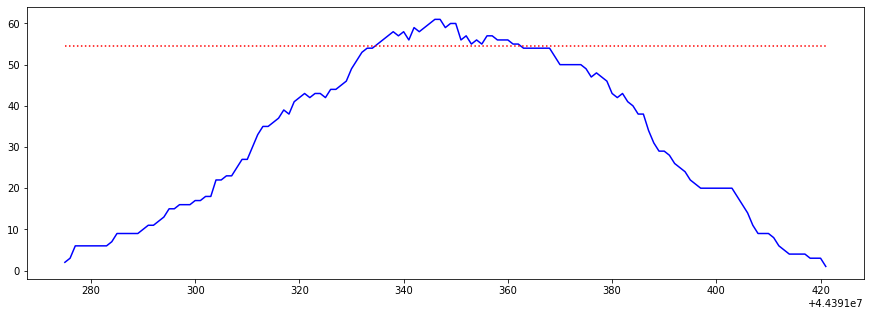

In [98]:
x = []
y = []
samfile = pysam.AlignmentFile(path, "rc", reference_filename = ref)
for column in samfile.pileup("chr21", pos, pos):
    x.append(column.pos)
    n = 0
    for read in column.pileups:
        if (not read.is_del):
            n += 1
    y.append(n)

plot.figure(figsize=(15, 5))
plot.plot(x, y, 'b')
plot.plot([x[0], x[-1]], [numpy.mean(y[50:-50]), numpy.mean(y[50:-50])], ':r')
samfile.close()

In [107]:
pos

44391495

In [175]:
consistent = 0
pos = 44391350
samfile = pysam.AlignmentFile(path, "rc", reference_filename = ref)
for column in samfile.pileup("chr21", pos, pos):
    pos = column.pos
    counts = {base : 0 for base in "ACGTN"}
    total = 0
    for read in column.pileups:
        base = read.alignment.seq[read.query_position]
        counts[base] += 1
        total += 1
    #print(dir(read.alignment))
    print(read.alignment.query_alignment_end)
    print(read.)
        
            
    frac = [counts[base] / total for base in "ACGTN"]
    print(pos, counts, total, frac)
samfile.close()

SyntaxError: invalid syntax (588144585.py, line 14)

In [112]:
import hail as hl

In [113]:
import os
from ukb_utils import hail_init
from ko_utils import ko
from ko_utils import io

In [114]:
in_file = "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/mt/annotated/ukb_eur_wes_union_calls_200k_chr21.mt"

In [115]:
mt = io.import_table(in_file, "mt")

Initializing Hail with default parameters...


2022-10-13 22:57:01 WARN  NativeCodeLoader:60 - Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
Running on Apache Spark version 3.1.3
SparkUI available at http://compa028.hpc.in.bmrc.ox.ac.uk:4040
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.102-817f6fb3468f
LOGGING: writing to /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/notebooks/hail-20221013-2256-0.2.102-817f6fb3468f.log


In [137]:
#mt = mt.drop("consequence")
#mt = mt.drop("filters")
#mt = mt.drop("qual")

In [138]:
mt = mt.filter_entries(mt.GT.is_het())
mt = io.recalc_info(mt)

In [139]:
mt.describe()

----------------------------------------
Global fields:
    None
----------------------------------------
Column fields:
    's': str
----------------------------------------
Row fields:
    'locus': locus<GRCh38>
    'alleles': array<str>
    'rsid': str
    'info': struct {
        AC: int32, 
        AF: float64, 
        AN: int32
    }
    'varid': str
----------------------------------------
Entry fields:
    'GT': call
----------------------------------------
Column key: ['s']
Row key: ['locus', 'alleles']
----------------------------------------


In [146]:
mt.entries().flatten().describe()

----------------------------------------
Global fields:
    None
----------------------------------------
Row fields:
    'locus': locus<GRCh38> 
    'alleles': array<str> 
    'rsid': str 
    'info.AC': int32 
    'info.AF': float64 
    'info.AN': int32 
    'varid': str 
    's': str 
    'GT': call 
----------------------------------------
Key: []
----------------------------------------
